## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### MLP

#### Import Libraries 

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier

import seaborn as sns
import matplotlib.pyplot as plt
import joblib

#### Load Data

In [2]:
data = pd.read_csv("../Dataset/anomaly_output.csv")

feature_cols = [
    'total_emails','total_attachments','avg_email_size',
    'off_hour_emails','weekend_emails',
    'O','C','E','A','N'
]

X = data[feature_cols]
y = data['anomaly_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Train MLP

In [3]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=300,
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)

#### Evaluation

In [4]:
mlp_pred = mlp.predict(X_test)

#### Confusion Matrix & Classification Report

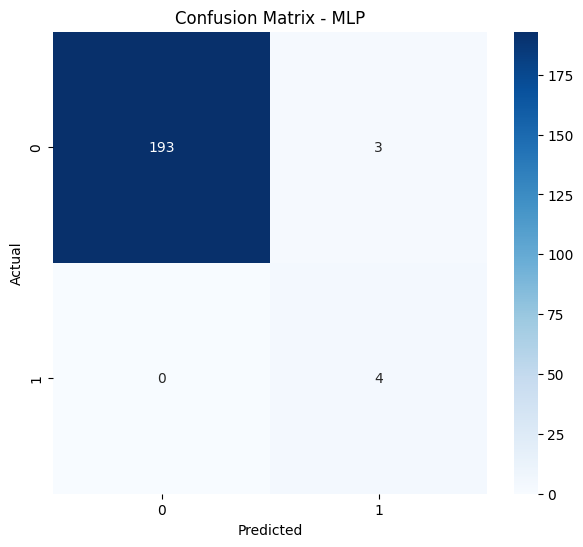


📄 CLASSIFICATION REPORT - MLP

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       196
           1       0.57      1.00      0.73         4

    accuracy                           0.98       200
   macro avg       0.79      0.99      0.86       200
weighted avg       0.99      0.98      0.99       200



In [5]:
cm = confusion_matrix(y_test, mlp_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n📄 CLASSIFICATION REPORT - MLP\n")
print(classification_report(y_test, mlp_pred))

#### Save Model

In [6]:
joblib.dump(mlp, "../Model/mlp_model.pkl")
print("MLP model saved ✅")

MLP model saved ✅
